<a href="https://colab.research.google.com/github/fadilaha/Ising-Model-on-Social-Opinion-Dynamic/blob/main/HeatBath_with_AB_Model_rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#__Heat-Bath Dynamics with A-B Model Transition Rules__

This model has updated the rules of spin transition, adopting the A-B Model-inspired rules.  
__Transition Rules__  
*   +1 -> [+1, 0]; +1 can maintains its state or moves to 0  
*   0 -> [+1, 0, -1]; 0 can maintains its state or moves to +1 and -1  
*   -1 -> {0, -1}; +1 can maintains its state or moves to 0
*   Both +1 and -1 need to pass through 0 state first before transitioning to its opposites.  
In this logic, +1 and -1 can choose 0, and later:
1. Maintain its 0 state
2. Move to its opposite
3. Go back to its initial state  
The decision depends on the randomly drawn state by the system, based on the calculated probabilities for each possible states  

__The Probabilities__  

Just like the previous Heat-Bath Dynamics, for each selected spin, the probabilities of the three possible states are calculated based on their corresponding energies under the current effective field.  
Energy = -[possible states of chosen spin] x effective field (h_eff)  

Boltzmann weight, $w = e^{\frac{-Energy}{kB.T}}$  

Probability of a state, $P_i = {\frac{e^{\frac{-Energy_i}{kB.T}}}{(\sum^n_{i=-1} w_i)}}$ ; $i$ = possible new state of the chosen current spin

The system will draw a new state by randomly choose one element from possible_states. However, each element's chance of being chosen equal to the corresponding value in the previously calculated probabilities.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load Same External Event Schedule from Glauber Scheme.
# The file can be found in the https://github.com/fadilaha/Ising-Model-on-Social-Opinion-Dynamic
external_events = np.load("external_events.npy").tolist()
print("External events:", external_events)

def simulate_open_population(N_up_initial, N_down_initial, N_o, T, h, J, q, r_growth, steps, external_events, dt=1.0):
    kB = 1
    # INITIAL POPULATION
    spins = ([1] * N_up_initial + [-1] * N_down_initial + [0] * N_o)
    np.random.shuffle(spins)
    N_up = N_up_initial
    N_down = N_down_initial
    N_neutral = N_o

    # DATA STORAGE
    Data_N_up = []
    Data_N_down = []
    Data_N_neutral = []
    Data_M = []
    Data_N_total = []
    Data_h_ext = []
    Data_h_eff = []
    spin_history = []

    # INITIAL DATA
    N = len(spins)
    M = (N_up - N_down) / N

    Data_N_up.append(N_up)
    Data_N_down.append(N_down)
    Data_N_neutral.append(N_neutral)
    Data_M.append(M)
    Data_N_total.append(N)
    Data_h_ext.append(h)
    Data_h_eff.append(h + J * q * M)
    spin_history.append(spins.copy())

    # MAIN SIMULATION
    for step in range(1, steps + 1):

        # 1. CALCULATE TOTAL EXTERNAL FIELD
        h_ext = 0.0
        decay_rate = 0.1

        for event_time, event_amplitude in external_events:
            if step >= event_time:
                age = step - event_time       #next event will occurs minimum after 3 days from the last event
                decay = event_amplitude * np.exp(-decay_rate * age)  #the event's amplitude will decay exponentially on the next day
                h_ext += decay

        # 2. INTRINSIC GROWTH
        N = len(spins)
        M = (N_up - N_down) / N

        # dN/dt = r*N*M
        dNdt = r_growth * N * M            #Intrinsic growth in one monte carlo sweep depends on the latest Magnetization value
        dN = dNdt * dt

        # Positive M -> new positive population
        if dN > 0:
            new_population = int(np.floor(dN))
            if new_population > 0:
                spins.extend([1] * new_population)
                N_up += new_population

        # Negative M -> new negative population
        elif dN < 0:
            new_population = int(np.floor(abs(dN)))
            if new_population > 0:
                spins.extend([-1] * new_population)
                N_down += new_population

        # Update total N and M after growth
        N = len(spins)
        M = (N_up - N_down) / N

        # 4. HEAT-BATH SPIN DYNAMICS
        # N random spin-update attempts = 1 MCS
        for _ in range(N):
            # Current M
            M = (N_up - N_down) / N
            # Current mean-field effective field works on an individual
            h_eff = h_ext + J * q * M

            # Randomly choose one individual
            i = np.random.randint(0, N)
            sigma_old = spins[i]

            # TRANSITION RULE
            # +1 -> {+1, 0}; +1 can maintains its state or moves to 0
            #  0 -> {+1, 0, -1}; 0 can maintains its state or moves to +1 and -1
            # -1 -> {0, -1}; +1 can maintains its state or moves to 0
            # Both +1 and -1 need to pass through 0 state first before transitioning to its opposites.
            # In this logic, +1 and -1 can choose 0, and later:
            # (1) maintain its 0 state, (2) move to its opposite, (3) go back to its initial state
            # The decision depends on the randomly drawn state by the system, based on the calculated probabilities for each possible states.
            if sigma_old == 1:
                possible_states = np.array([1, 0])
            elif sigma_old == 0:
                possible_states = np.array([1, 0, -1])
            elif sigma_old == -1:
                possible_states = np.array([0, -1])

            # Heat-bath probabilities for allowed states
            energies = -possible_states * h_eff     #calculate energies for each possibilities of the chosen spin
            weights = np.exp(np.clip(-energies / (kB * T), -100, 100))   #also calculate the boltzmann weights
            probabilities = weights / np.sum(weights)   #substitute the boltzmann weights (w) here to acquire the probability for each possibilities.
                                                        #probability = w/sum of w_i ; i= each possibilities for the chosen spin

            # Draw new state, randomly choose one element from possible_states
            # Each element's chance of being chosen equal to the corresponding value in the previously calculated probabilities
            sigma_new = np.random.choice(possible_states, p=probabilities)
            # Update the new chosen state
            if sigma_new != sigma_old:
                # Remove old state
                if sigma_old == 1:
                    N_up -= 1
                elif sigma_old == -1:
                    N_down -= 1
                elif sigma_old == 0:
                    N_neutral -= 1
                # Add new state
                if sigma_new == 1:
                    N_up += 1
                elif sigma_new == -1:
                    N_down += 1
                elif sigma_new == 0:
                    N_neutral += 1
            # Update spin
            spins[i] = sigma_new

        # 5. FINAL M AFTER THIS TIMESTEP
        M = (N_up - N_down) / N

        # Udpate Final effective field after Heat-Bath dynamics
        h_eff = h + h_ext + J * q * M

        # 6. STORE DATA
        Data_N_up.append(N_up)
        Data_N_down.append(N_down)
        Data_N_neutral.append(N_neutral)
        Data_M.append(M)
        Data_N_total.append(N)
        Data_h_ext.append(h_ext)
        Data_h_eff.append(h_eff)
        spin_history.append(spins.copy())

        # PROGRESS
        if step % 10 == 0:
            print(f"MCS {step}/{steps} selesai | N = {N}")

    return (Data_N_up, Data_N_down, Data_N_neutral, Data_M, Data_N_total,
        Data_h_ext, Data_h_eff, external_events, spin_history)

External events: [[9.0, 0.21], [15.0, 0.21], [35.0, -0.21], [40.0, -0.21], [46.0, 0.21], [60.0, 0.21], [68.0, -0.21], [82.0, -0.21], [87.0, -0.21], [99.0, -0.21], [116.0, -0.21], [145.0, -0.21], [149.0, 0.21], [161.0, 0.21], [169.0, -0.21], [174.0, 0.21], [191.0, -0.21]]


In [2]:
#PARAMETER INPUT
N_up_initial = 3130
N_down_initial = 1319
N_o = 602

External_field = 0
J_coupling = 0.3
q_neighbors = 4.0

r_growth = 0.001
Temperature = 1.2
Time_steps = 300

np.random.seed(42)
#EXTERNAL EVENTS IS GENERATED ON GLAUBER'S NOTEBOOK, it has loaded in the simulation cell above

#RUN SIMULATION
results = simulate_open_population(N_up_initial, N_down_initial, N_o, Temperature, External_field, J_coupling,
    q_neighbors, r_growth, Time_steps, external_events, dt=1.0)

(N_up_history, N_down_history, N_neutral_history, M_history, N_total_history,
    h_ext_history, h_eff_history, external_events, spin_history) = results

MCS 10/300 selesai | N = 5059
MCS 20/300 selesai | N = 5074
MCS 30/300 selesai | N = 5093
MCS 40/300 selesai | N = 5099
MCS 50/300 selesai | N = 5107
MCS 60/300 selesai | N = 5108
MCS 70/300 selesai | N = 5113
MCS 80/300 selesai | N = 5113
MCS 90/300 selesai | N = 5123
MCS 100/300 selesai | N = 5143
MCS 110/300 selesai | N = 5163
MCS 120/300 selesai | N = 5179
MCS 130/300 selesai | N = 5197
MCS 140/300 selesai | N = 5207
MCS 150/300 selesai | N = 5214
MCS 160/300 selesai | N = 5216
MCS 170/300 selesai | N = 5222
MCS 180/300 selesai | N = 5228
MCS 190/300 selesai | N = 5238
MCS 200/300 selesai | N = 5239
MCS 210/300 selesai | N = 5239
MCS 220/300 selesai | N = 5239
MCS 230/300 selesai | N = 5239
MCS 240/300 selesai | N = 5239
MCS 250/300 selesai | N = 5239
MCS 260/300 selesai | N = 5239
MCS 270/300 selesai | N = 5239
MCS 280/300 selesai | N = 5239
MCS 290/300 selesai | N = 5239
MCS 300/300 selesai | N = 5239


In [3]:
#SHOW THE DETAILS OF EXTERNAL FIELD APPEARANCES
print("External field events:")

for event_time, event_amplitude in external_events:
    print(
        f"t = {event_time}: "
        f"h = {event_amplitude:+.1f}")

External field events:
t = 9.0: h = +0.2
t = 15.0: h = +0.2
t = 35.0: h = -0.2
t = 40.0: h = -0.2
t = 46.0: h = +0.2
t = 60.0: h = +0.2
t = 68.0: h = -0.2
t = 82.0: h = -0.2
t = 87.0: h = -0.2
t = 99.0: h = -0.2
t = 116.0: h = -0.2
t = 145.0: h = -0.2
t = 149.0: h = +0.2
t = 161.0: h = +0.2
t = 169.0: h = -0.2
t = 174.0: h = +0.2
t = 191.0: h = -0.2


__GRAPHS SECTION__

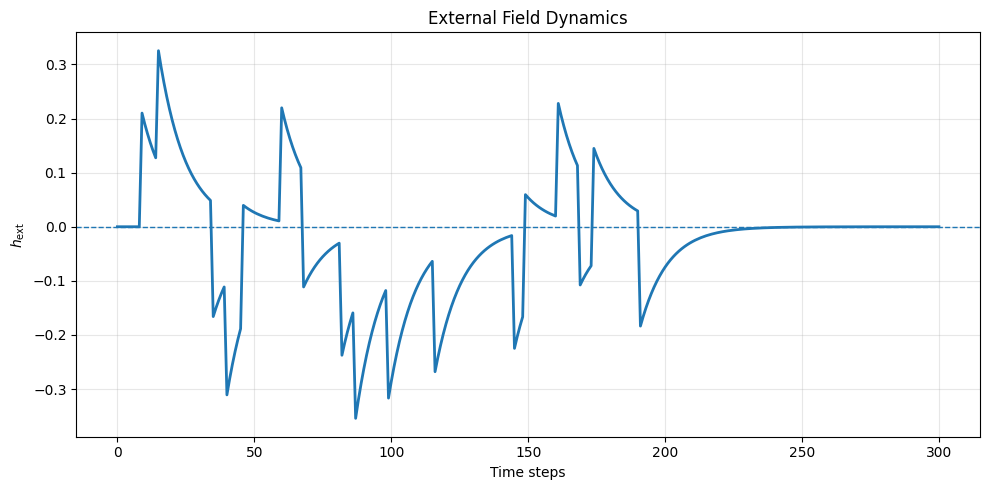

In [4]:
#PLOT EXTERNAL FIELD EVENTS
time = np.arange(len(h_ext_history))
plt.figure(figsize=(10, 5))
plt.plot(
    time,
    h_ext_history,
    linewidth=2
)
plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)
plt.xlabel("Time steps")
plt.ylabel(r"$h_{\mathrm{ext}}$")
plt.title("External Field Dynamics")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

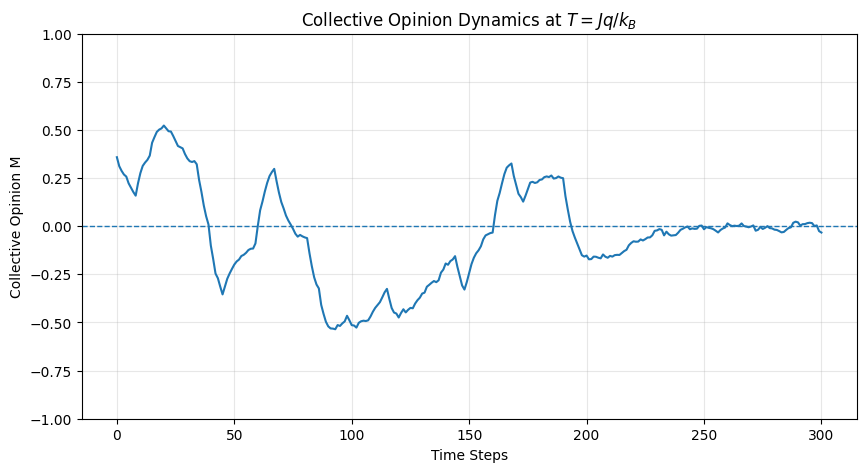

In [5]:
# PLOT COLLECTIVE OPINION (M) OVER TIME
plt.figure(figsize=(10, 5))
plt.plot(M_history)
plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)
plt.xlabel("Time Steps")
plt.ylabel("Collective Opinion M")
plt.title(r"Collective Opinion Dynamics at $T=Jq/k_B$")
plt.ylim(-1,1)
plt.grid(alpha=0.3)
plt.show()

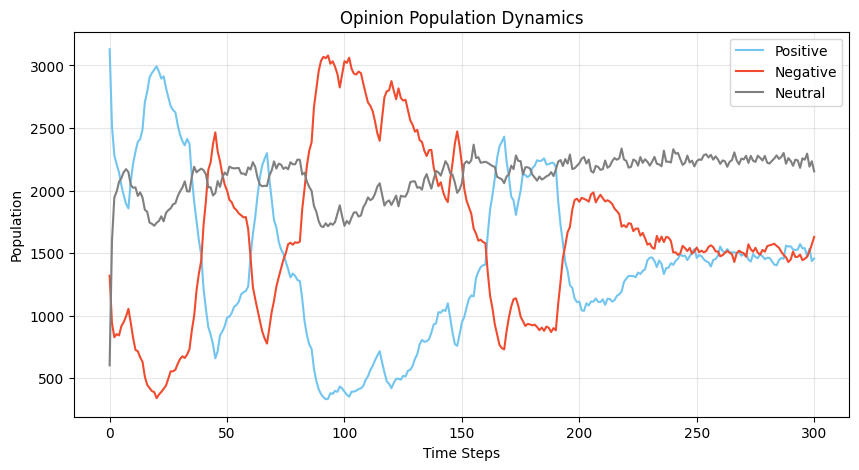

In [6]:
# PLOT OPINION POPULATION DYNAMIC OVER TIME
plt.figure(figsize=(10, 5))
plt.plot(N_up_history, color="#72C5EF", label="Positive")
plt.plot(N_down_history, color="#F04B2F", label="Negative")
plt.plot(N_neutral_history, color="#7F7F7F", label="Neutral")
plt.xlabel("Time Steps")
plt.ylabel("Population")
plt.title("Opinion Population Dynamics")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

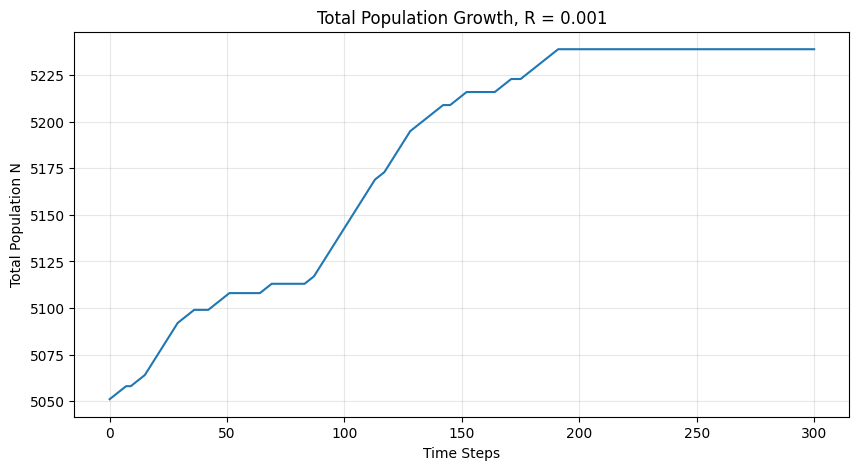

In [7]:
# PLOT TOTAL POPULATION GROWTH OVER TIME
plt.figure(figsize=(10, 5))
plt.plot(N_total_history)
plt.xlabel("Time Steps")
plt.ylabel("Total Population N")
plt.title(f"Total Population Growth, R = {r_growth}")
plt.grid(alpha=0.3)
plt.show()

__INTERACTIVE OUTPUT SECTION__

In [8]:
#DYNAMIC MAP OF THE LATTICE
from IPython.display import HTML, display
import json
import numpy as np

# Prepare spin data
spin_data = [np.asarray(s).tolist() for s in spin_history]

M_data = np.asarray(M_history).tolist()
N_data = np.asarray(N_total_history).tolist()

html = f"""
<div style="font-family: Arial; width: 650px;">

    <h3>Dynamic Ising Opinion Evolution Map</h3>

    <canvas id="opinionCanvas"
            width="600"
            height="600"
            style="border:1px solid black;">
    </canvas>

    <br><br>

    <input
        type="range"
        id="timeSlider"
        min="0"
        max="{len(spin_data)-1}"
        value="0"
        step="1"
        style="width:600px;"
    >

    <br><br>

    <button id="playButton">
        ▶ Play
    </button>

    <p>
        MCS:
        <span id="mcsValue">0</span>
        &nbsp;&nbsp;&nbsp;

        M:
        <span id="magValue">---</span>

        &nbsp;&nbsp;&nbsp;

        N:
        <span id="NValue">---</span>
    </p>

</div>

<script>

(function(){{

    const spinData = {json.dumps(spin_data)};
    const magnetization = {json.dumps(M_data)};
    const population = {json.dumps(N_data)};

    const canvas = document.getElementById("opinionCanvas");
    const ctx = canvas.getContext("2d");

    const slider = document.getElementById("timeSlider");
    const playButton = document.getElementById("playButton");

    const mcsText = document.getElementById("mcsValue");
    const magText = document.getElementById("magValue");
    const NText = document.getElementById("NValue");

    let playing = false;
    let animationTimer = null;

    // =========================
    // Draw map
    // =========================

    function drawMap(mcs) {{

        const spins = spinData[mcs];

        const N = spins.length;

        const gridSize = Math.ceil(Math.sqrt(N));

        ctx.clearRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        ctx.fillStyle = "white";

        ctx.fillRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        const cellSize = canvas.width / gridSize;

        for (let i = 0; i < N; i++) {{

            const row = Math.floor(i / gridSize);
            const col = i % gridSize;

            const x = col * cellSize;
            const y = row * cellSize;

            const spin = spins[i];
            if (spin === 1) {{
                ctx.fillStyle = "#73C5EF";
            }}
            else if (spin === -1) {{
                ctx.fillStyle = "#F04B2F";
            }}
            else {{
                ctx.fillStyle = "#7F7F7F";
            }}

            ctx.fillRect(
                x,
                y,
                cellSize,
                cellSize
            );
        }}

        // Display information

        mcsText.textContent = mcs;

        if (mcs < magnetization.length) {{
            magText.textContent =
                magnetization[mcs].toFixed(4);
        }}
        else {{
            magText.textContent = "---";
        }}

        if (mcs < population.length) {{
            NText.textContent = population[mcs];
        }}
        else {{
            NText.textContent = "---";
        }}
    }}

    // =========================
    // Slider
    // =========================

    slider.addEventListener(
        "input",
        function() {{
            drawMap(parseInt(this.value));
        }}
    );

    // =========================
    // Play / Pause
    // =========================

    playButton.addEventListener(
        "click",
        function() {{

            if (playing) {{

                playing = false;

                clearInterval(animationTimer);

                playButton.textContent = "▶ Play";

            }} else {{

                playing = true;

                playButton.textContent = "⏸ Pause";

                animationTimer = setInterval(
                    function() {{

                        let current =
                            parseInt(slider.value);

                        if (current >= spinData.length - 1) {{

                            playing = false;

                            clearInterval(animationTimer);

                            playButton.textContent = "▶ Play";

                            return;
                        }}

                        current += 1;

                        slider.value = current;

                        drawMap(current);

                    }},
                    50
                );
            }}
        }}
    );

    // =========================
    // Initial map
    // =========================

    drawMap(0);

}})();

</script>
"""

display(HTML(html))